# Mushroom Decision Tree (Reduced Features) — Student Exercise
## Your Name:
## Date:
### In Blackboard you will submit your Github URL after saving your notebook to your class repository, AND a PDF of this notebook (in Colab, File . . . Print . . . PDF)
This activity uses a simplified version of the Mushroom dataset to create a decision tree.

## Goals
- Build a decision tree classifier
- Interpret a confusion matrix and accuracy
- Explain what the root and first-level nodes mean
- Translate tree splits into plain English


## 1️⃣ Setup

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load the Mushroom dataset (code is completed for you)
**Target:** `class`
- `e` = edible which becomes 0 or not poisonous
- `p` = poisonous which becomes 1

In [2]:
#note feature names, we will reduce these
mush = fetch_openml('mushroom', version=1, as_frame=True)
df = mush.frame.copy()
# rename the column
df = df.rename(columns={"bruises%3F": "bruises"})
df.head()


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,x,s,n,t,p,f,c,n,k,e,...,w,w,p,w,o,p,k,s,u,p
1,x,s,y,t,a,f,c,b,k,e,...,w,w,p,w,o,p,n,n,g,e
2,b,s,w,t,l,f,c,b,n,e,...,w,w,p,w,o,p,n,n,m,e
3,x,y,w,t,p,f,c,n,n,e,...,w,w,p,w,o,p,k,s,u,p
4,x,s,g,f,n,f,w,b,k,t,...,w,w,p,w,o,e,n,a,g,e


## 3️⃣ Use a reduced feature set (code is completed for you)
These features are highly predictive and keep the tree readable. Note the class is mapped to 0 (edible) and 1 (poisonous).

In [3]:

features = ['odor', 'spore-print-color', 'gill-size', 'gill-color', 'bruises']

X = df[features]
y = df['class'].map({'e':0, 'p':1})

X.head(), y.value_counts()


(  odor spore-print-color gill-size gill-color bruises
 0    p                 k         n          k       t
 1    a                 n         b          k       t
 2    l                 n         b          n       t
 3    p                 k         n          n       t
 4    n                 n         b          k       f,
 class
 0    4208
 1    3916
 Name: count, dtype: int64)

## 4️⃣ One‑hot encode the categorical features (Add Code)
Each category becomes a YES/NO column.

In [4]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=False)

X_encoded.head()



,odor_a,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,spore-print-color_b,...,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,bruises_f,bruises_t
0,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,True,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,False,False,False,False,False,True,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False


## 5️⃣ Train/test split (Add Code)

In [9]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((5686, 34), (2438, 34))

## 6️⃣ Train a small decision tree (Add Code)

In [26]:
# Create decision tree model
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)



DecisionTreeClassifier(max_depth=5, random_state=42)

## 7️⃣ Evaluate the model (Add Code)

In [27]:
# Make predictions
y_pred = tree_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))



Accuracy: 0.9954881050041017
Confusion Matrix:
 [[1263    0]
 [  11 1164]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1263
           1       1.00      0.99      1.00      1175

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



## 8️⃣ Visualize the decision tree (Add Code)

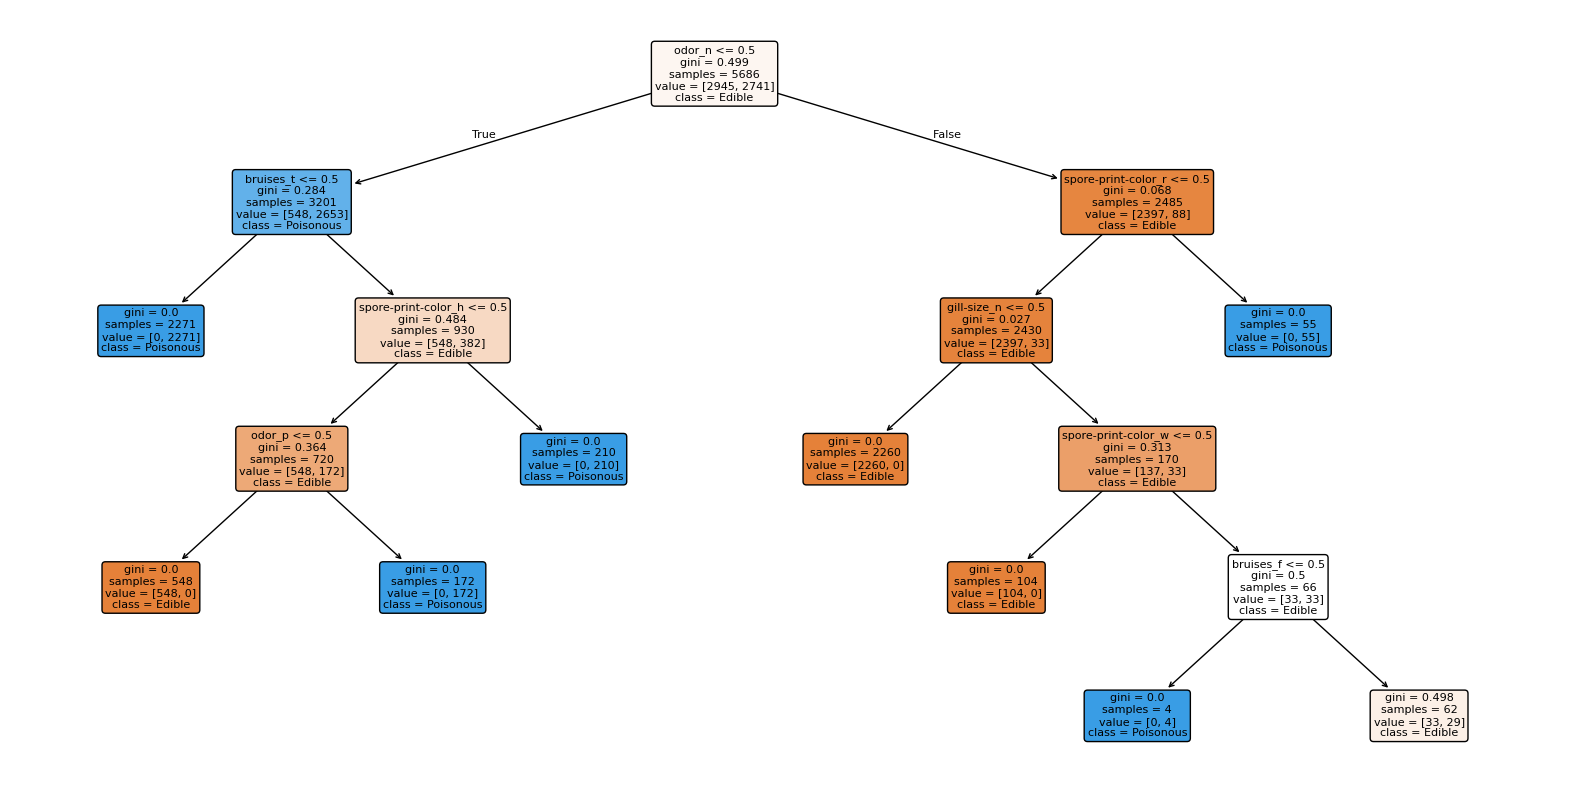

In [28]:
plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X_encoded.columns,
    class_names=["Edible", "Poisonous"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()


## 9️⃣ Print IF–THEN rules (Add Code)

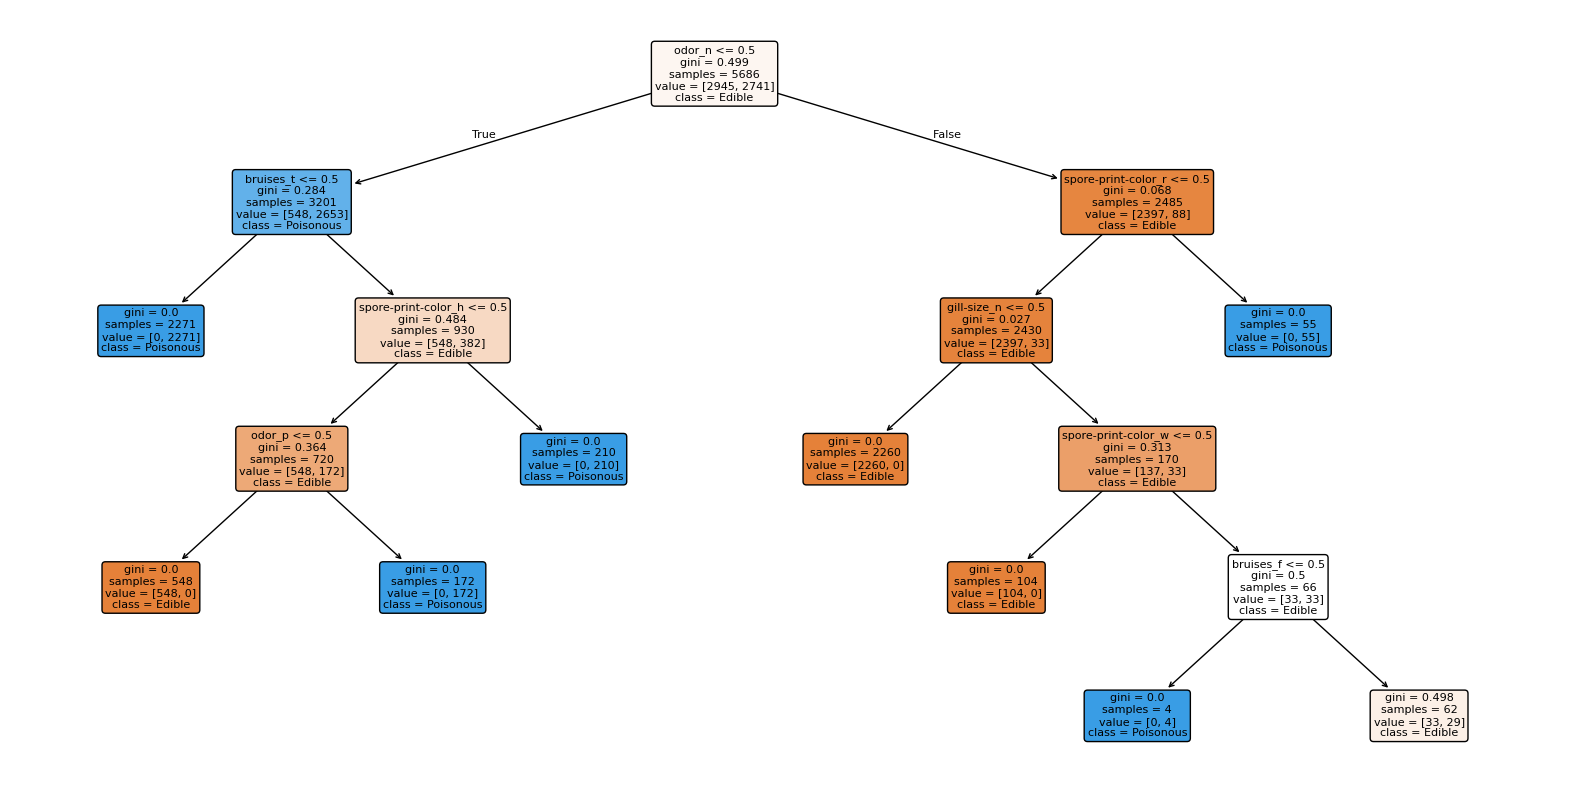

In [29]:

plt.figure(figsize=(20,10))

plot_tree(
    tree_model,
    feature_names=X_encoded.columns,
    class_names=["Edible", "Poisonous"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

---
# QUESTIONS TO ANSWER (provide answers in markdown)
### Confusion Matrix & Accuracy
1. What was the model accuracy?
> 95.94%
2. How many poisonous mushrooms were correctly classified?
> 1076
3. How many poisonous mushrooms were incorrectly predicted as edible?
> 99
4. Why is misclassifying a poisonous mushroom more serious than misclassifying an edible one?
> Because predicting a poisonous mushroom as edible could cause serious harm or death, while the opposite mistake is just inconvenient

### Understanding the Tree
5. What feature appears at the **root node**?
> odor
6. What question is the root node asking in plain English?
> Does the mushroom have a certain type of odor
7. Describe what the **left branch** and **right branch** mean.
> Left branch (True):
Mushroom has that odor condition → tends toward poisonous |
Right branch (False):
Mushroom does NOT have that odor → tends toward edible

### First Level Nodes
8. Look at the two nodes directly below the root.
   - What feature does each split on?
   > The left side's feature is bruises, the right side's has spore-print-color
   - What question is each node asking?
   > The left side asks "Does the mushroom have bruises?" The right side asks "Is the spore print color a certain type?”
   - What does following the left vs right branch mean?
   > Following the left means strongly poisonous and the other side needs further checking. Following the right side means its mostly edible, and the other it splits again

### Interpretation
9. Choose ONE full path from the root to a leaf and translate it into plain English.
> If a mushroom has a certain odor, does not have bruises, and has a specific spore print color, then it is classified as edible
10. Based on the tree, what feature seems most important for predicting if a mushroom is poisonous?
> Odor

### Exploration
11. Change `max_depth` to 2. What changed?
> It becomes a little simpler, its easier to interpret, but slightly less accurate
12. Change `max_depth` to 5. What changed?
> It becomes a little more complex, it captures more patterns, but there's a risk of overfitting
